In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

my_palette = [
    '#6B72BA',
    '#F3A086',
    '#E77A65',
    '#2C4A60',
    '#B5B5B5'
]

sns.set_palette(my_palette)

sns.set_theme(
    style="white",
    palette=my_palette,
    font_scale=1.1,
    rc={
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.spines.bottom': True,
        'axes.spines.left': True,
        'axes.edgecolor': 'black',
        'axes.linewidth': 1
    }
)

## ✅ Data Loading

In [ ]:
df = pd.read_csv("/content/.config/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## ✅ NULL value check

In [ ]:
count = df.isnull().sum()
percent = round((df.isnull().sum() / len(df)) *100, 2)

missing_df = pd.DataFrame({'Missing_count': count, 'Percentage(%)': percent})
missing_df = missing_df[missing_df['Missing_count'] > 0].sort_values(by='Missing_count')
display(missing_df)

,Missing_count,Percentage(%)
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


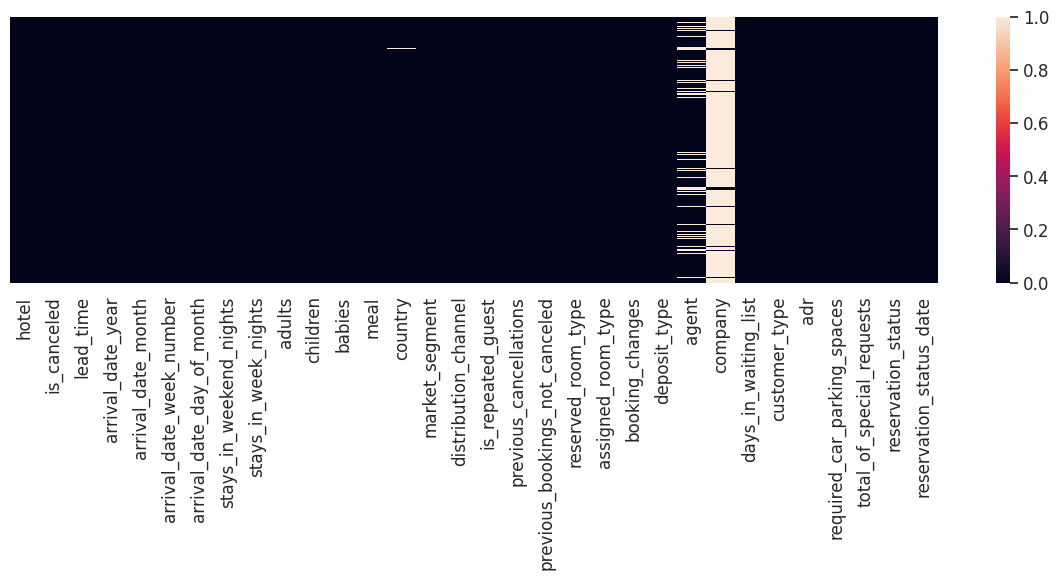

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(),yticklabels=False)
plt.tight_layout()

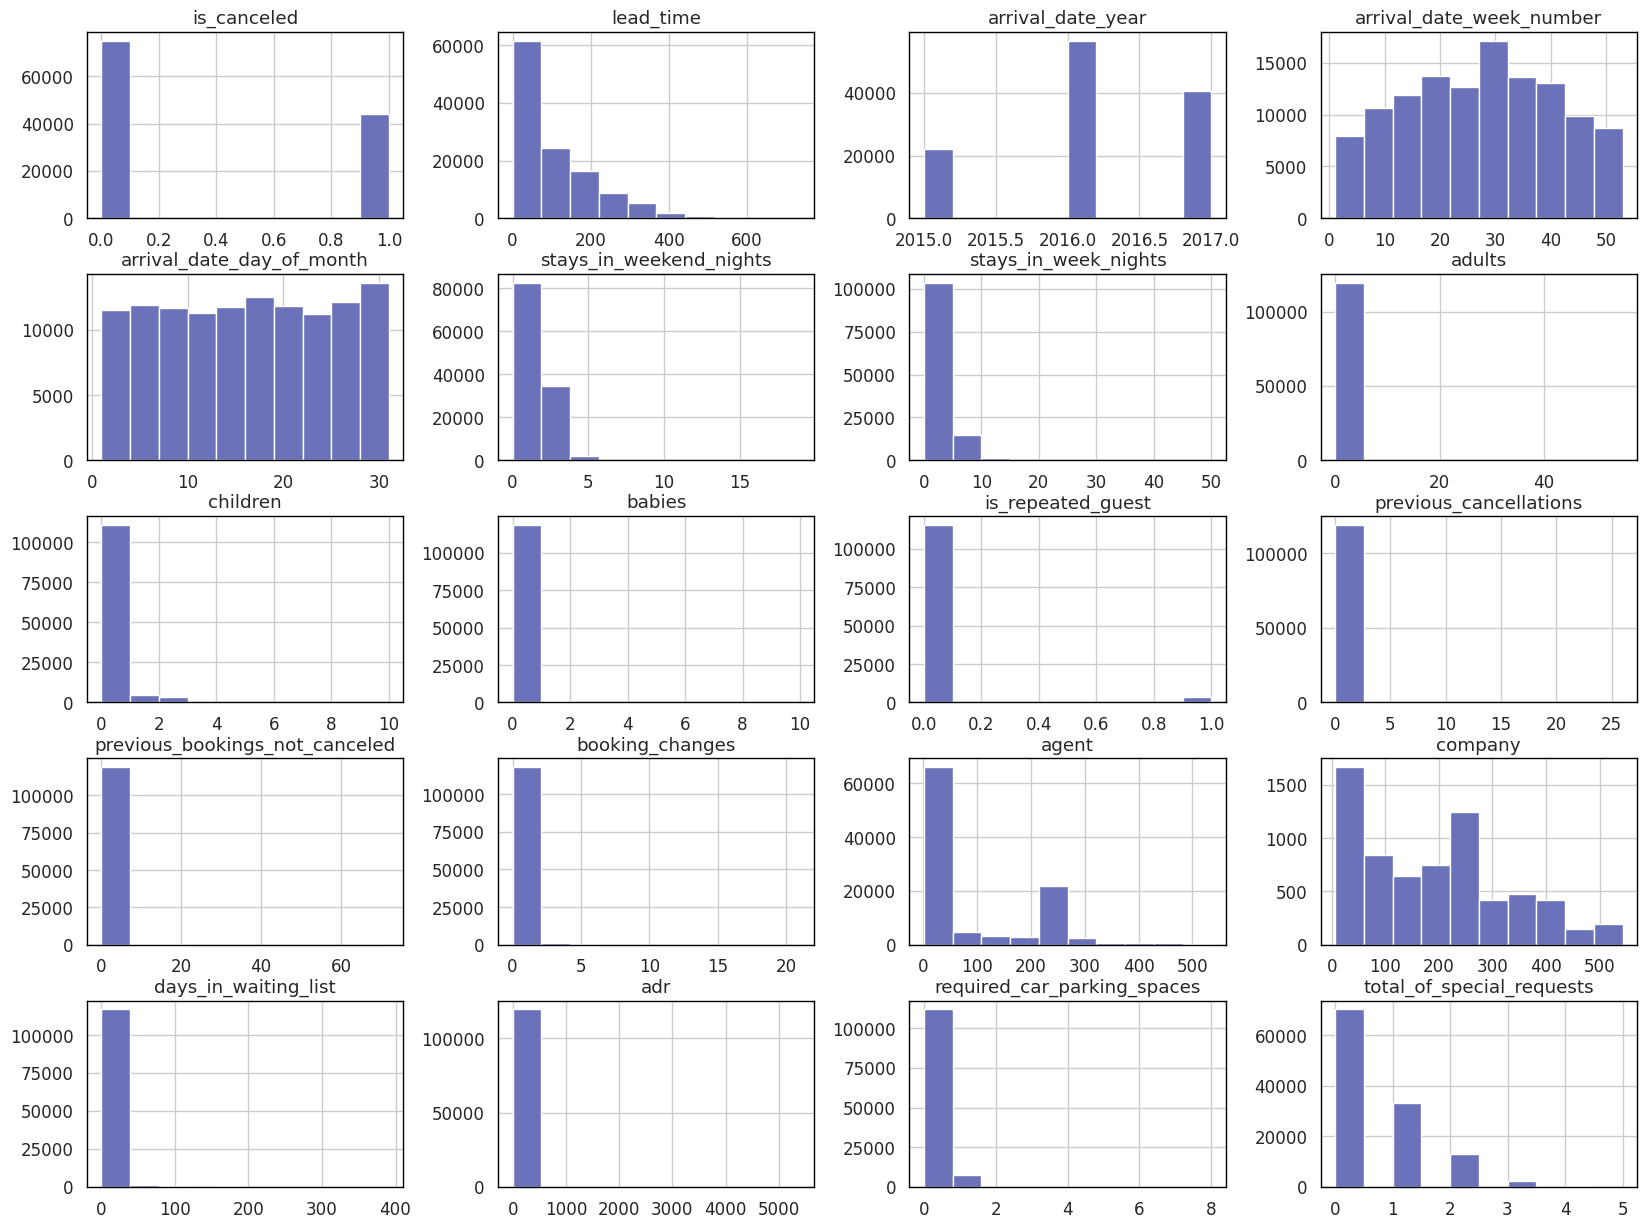

In [ ]:
df.hist(figsize=(20,15))
plt.show()

## ✅ Data Cleaning


In [ ]:
# remove the unnecessary columns: 'agent' and 'company'
df = df.drop(['agent', 'company'], axis = 1)

In [ ]:
# remove all the NULL values, 'country' has 488 NULL values, remove all the null rows will not affect the whole dataset
df = df.dropna(axis = 0)

In [ ]:
# generate new column 'is_canceled' and 'is_repeated_guest'
df['is_canceled_numeric'] = df['is_canceled'].copy()
df['is_canceled'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

df['is_repeated_guest_numeric'] = df['is_repeated_guest'].copy()
df['is_repeated_guest'] = df['is_repeated_guest'].map({0: 'New Guest', 1: 'Repeated Guest'})


In [ ]:
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
cat_cols = list(df.select_dtypes(include=['object']).columns)
false_cols = ['is_canceled_numeric', 'is_repeated_guest_numeric', 'arrival_date_year']
for col in false_cols:
  if col in num_cols:
    cat_cols.append(col)
    num_cols.remove(col)

In [ ]:
num_cols

['lead_time',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [ ]:
cat_cols

['hotel',
 'is_canceled',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date',
 'is_canceled_numeric',
 'is_repeated_guest_numeric',
 'arrival_date_year']

# ✅ Outliers



In [ ]:
df[num_cols].describe()

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000
mean,104.311435,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683
std,106.903309,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000
50%,69.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000
75%,161.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,737.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


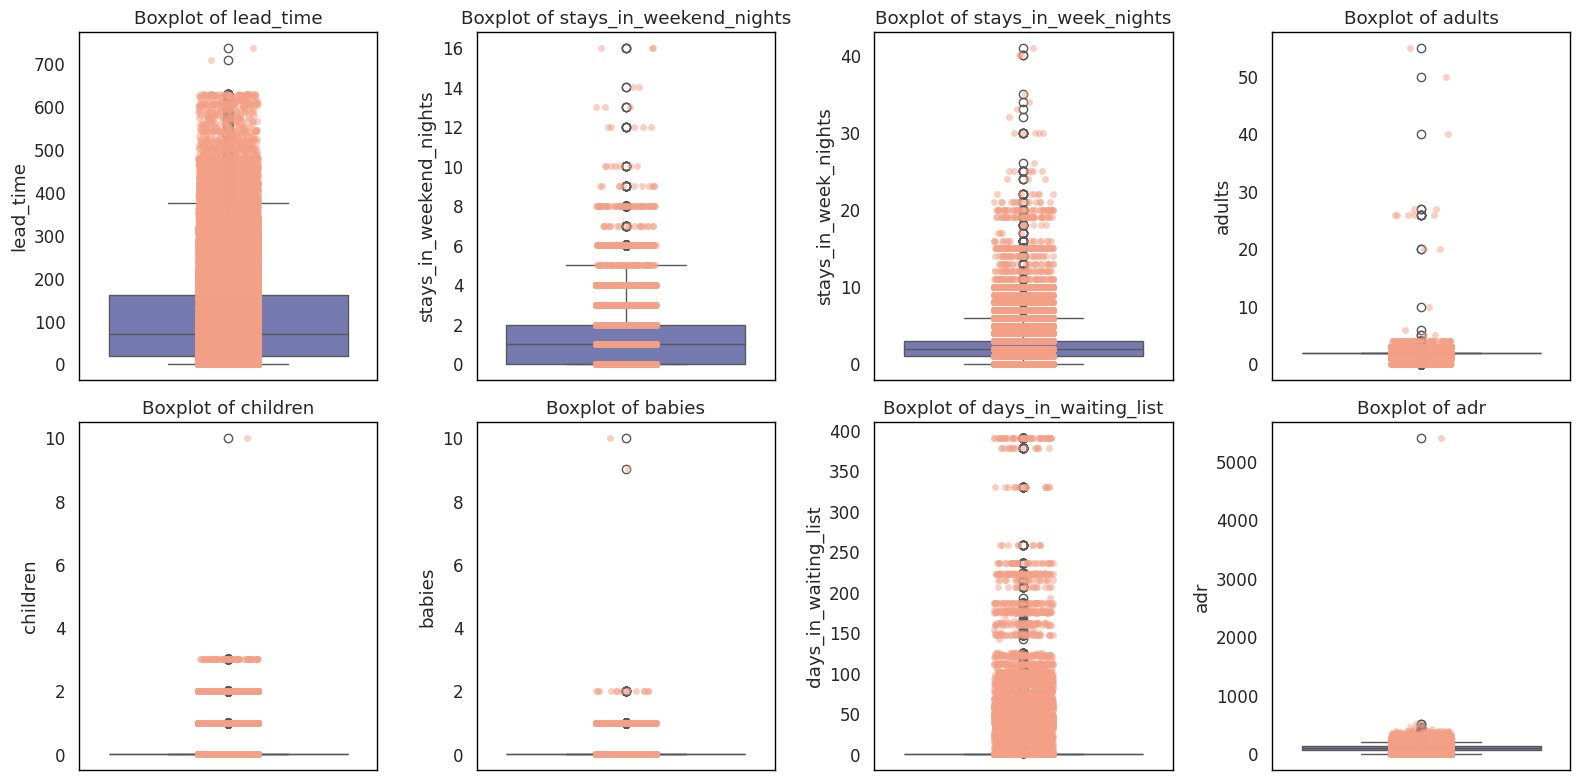

In [ ]:
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'days_in_waiting_list', 'adr']
n = 1
plt.figure(figsize=(16, 8))

for feature in features:
  plt.subplot(2, 4, n)
  sns.boxplot(y=df[feature])
  sns.stripplot(y=df[feature], alpha=0.5, jitter=True)
  plt.title(f"Boxplot of {feature}")
  n += 1

plt.tight_layout()
plt.show()

In [ ]:
# remove the outlier for column 'adr' 'babies' 'children' 'adults'
df = df[(df['adr'] > 0) & (df['adr'] < 1000 )]
df = df[df['babies'] <= 2]
df = df[df['children'] <= 4]
df = df[df['adults'] <= 5]

# make sure the sum of the three columns 'babies' 'children' 'adults' is more than 0
df = df[(df['adults'] + df['babies'] + df['children']) > 0]

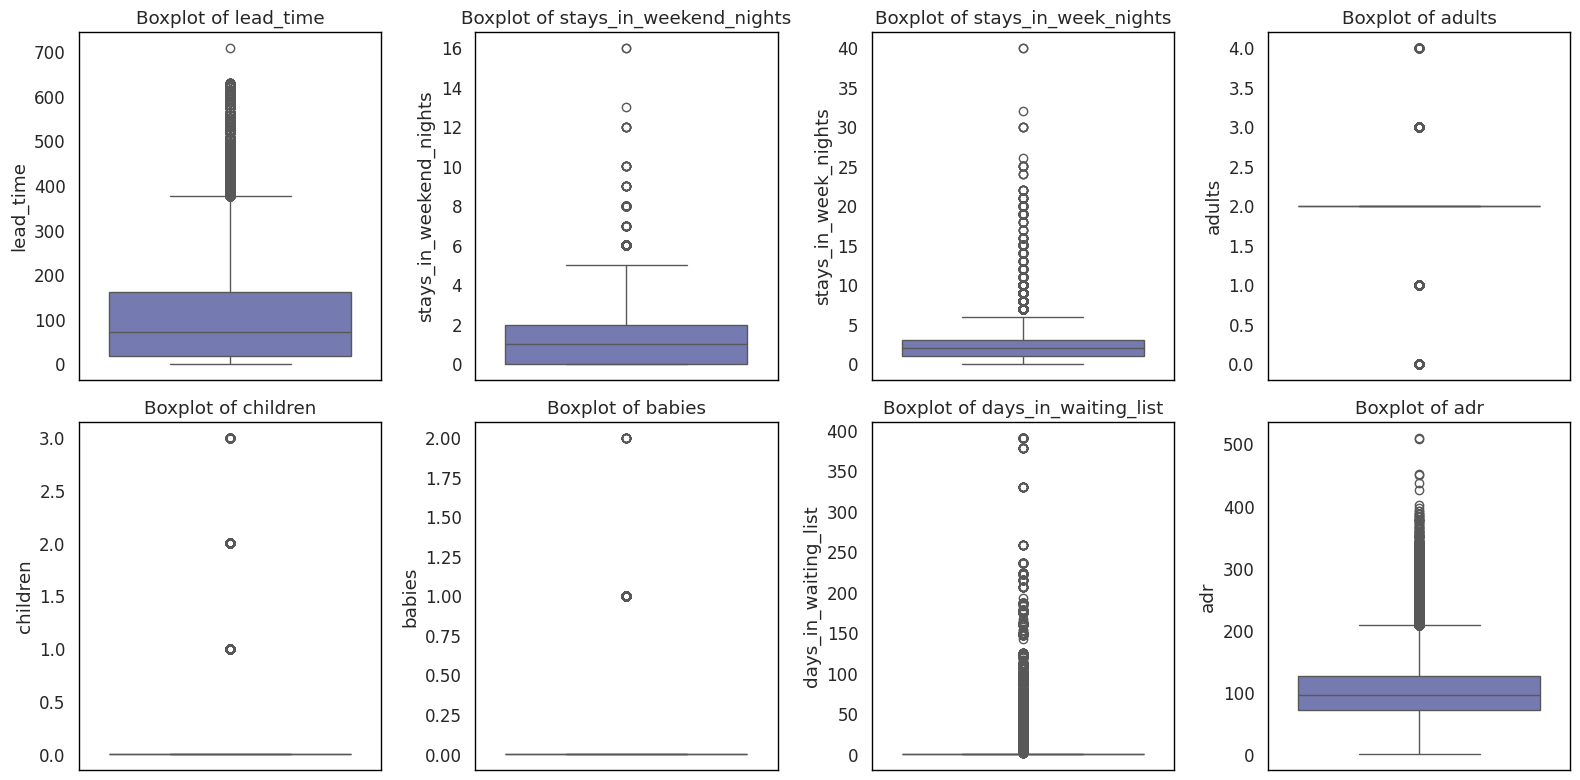

In [ ]:
# check again if the outlier has been removed
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights','adults', 'children', 'babies', 'days_in_waiting_list', 'adr']
n = 1
plt.figure(figsize=(16, 8))

for feature in features:
  plt.subplot(2, 4, n)
  sns.boxplot(y=df[feature])
  plt.title(f"Boxplot of {feature}")
  n += 1

plt.tight_layout()
plt.show()

In [ ]:
df[num_cols].describe()

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000,116924.000000
mean,105.388851,27.137482,15.805164,0.937301,2.522117,1.862937,0.104769,0.007706,0.086980,0.119736,0.215833,2.348055,103.660439,0.061980,0.571226
std,106.951637,13.560431,8.783002,0.992102,1.881676,0.480235,0.399303,0.088803,0.850305,1.432402,0.631278,17.714591,46.640076,0.244398,0.791483
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.260000,0.000000,0.000000
25%,19.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000
50%,71.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000
75%,162.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,709.000000,53.000000,31.000000,16.000000,40.000000,4.000000,3.000000,2.000000,26.000000,72.000000,18.000000,391.000000,510.000000,8.000000,5.000000


In [ ]:
df[cat_cols].dtypes

,0
hotel,object
is_canceled,object
arrival_date_month,object
meal,object
country,object
market_segment,object
distribution_channel,object
is_repeated_guest,object
reserved_room_type,object
assigned_room_type,object


##  ✅ Generate new columns

In [ ]:
# create a new column to combine the children and babies numbers together
df['kids'] = df['children'] + df['babies']

# create a new column to calculate the total number of guest
df['total_person'] = df['kids'] + df['adults']

# create a new column to calculate the total number of nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# update the num_cols and cat_cols
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
cat_cols = list(df.select_dtypes(include=['object']).columns)

In [ ]:
# combine the column 'year' 'month' and 'day' to generate the complete arrival date column
df['complete_arrival_date'] = df.apply(lambda row: f"{row['arrival_date_year']}-{row['arrival_date_month']}-{row['arrival_date_day_of_month']}", axis=1)

# '%B' corresponds to the complete Month name, like July
df['complete_arrival_date'] = pd.to_datetime(df['complete_arrival_date'], format= '%Y-%B-%d', errors = 'coerce')

# extract the month number
df['arrival_date_month'] = df['complete_arrival_date'].dt.month

df['complete_arrival_date']

,complete_arrival_date
2,2015-07-01
3,2015-07-01
4,2015-07-01
5,2015-07-01
6,2015-07-01
...,...
119385,2017-08-30
119386,2017-08-31
119387,2017-08-31
119388,2017-08-31


##  ✅ Generate tables  

In [ ]:
counts = df['is_canceled'].value_counts()
percent = round(df['is_canceled'].value_counts(normalize=True)*100, 2)

summary_df = pd.DataFrame({'Count': counts, 'Percentage(%)': percent})
summary_df

,Count,Percentage(%)
is_canceled,,
Not Canceled,72976,62.41
Canceled,43948,37.59


In [ ]:
from IPython.display import display

for col in cat_cols:
  percent_df = df[col].value_counts(normalize=True).reset_index().head(10)

  # rename the columns
  percent_df.columns = [col, 'Percentage']

  percent_df['Percentage'] = percent_df['Percentage'].map('{:.2%}'.format)

  print(f"\n📊Category Analyse: {col}\n")

  # use display to substitute print
  display(percent_df)


📊Category Analyse: hotel



,hotel,Percentage
0,City Hotel,66.77%
1,Resort Hotel,33.23%



📊Category Analyse: is_canceled



,is_canceled,Percentage
0,Not Canceled,62.41%
1,Canceled,37.59%



📊Category Analyse: arrival_date_month



...

,customer_type,Percentage
0,Transient,75.02%
1,Transient-Party,21.06%
2,Contract,3.46%
3,Group,0.46%



📊Category Analyse: reservation_status



,reservation_status,Percentage
0,Check-Out,62.41%
1,Canceled,36.58%
2,No-Show,1.01%



📊Category Analyse: reservation_status_date



,reservation_status_date,Percentage
0,2015-10-21,1.24%
1,2015-07-06,0.69%
2,2016-11-25,0.67%
3,2015-01-01,0.65%
4,2016-01-18,0.53%
5,2015-07-02,0.40%
6,2016-12-07,0.38%
7,2015-12-18,0.36%
8,2016-02-09,0.35%
9,2016-04-04,0.32%


## ✅ Data Visualization

Text(0.5, 1.0, 'Not Canceled Booking vs. Canceled Booking ')

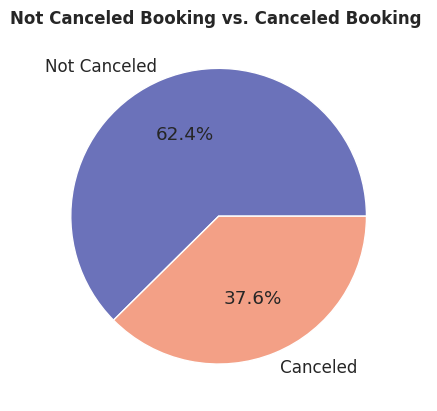

In [ ]:
ax = df['is_canceled'].value_counts().plot(kind='pie', autopct='%1.1f%%')

ax.set(xlabel=None, ylabel=None)
plt.title("Not Canceled Booking vs. Canceled Booking ",fontweight="bold", size=12)

Text(0.5, 1.0, 'Not Canceled Order Count vs. Canceled Order Count')

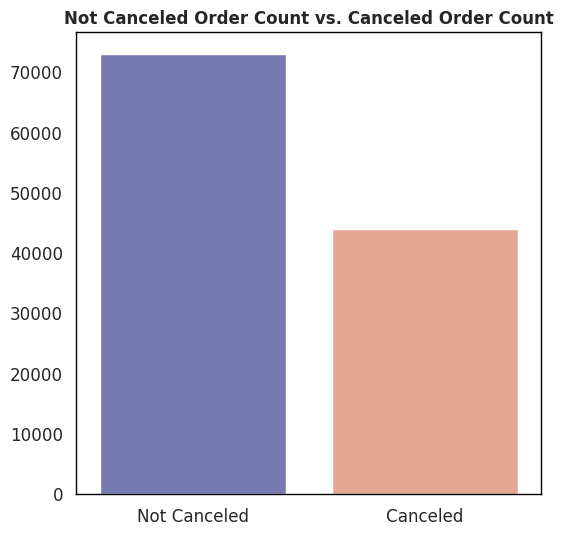

In [ ]:
plt.figure(figsize=(6,6))
ax = sns.countplot(
    x='is_canceled',
    hue= 'is_canceled',
    data=df
)

ax.set(xlabel=None, ylabel=None)
plt.title("Not Canceled Order Count vs. Canceled Order Count",fontweight="bold", size=12)

## ✅ Data Visualization: Use Function

In [ ]:
def plot_absolute_counts(df, x, hue, order, ax, custom_title=None):
        sns.countplot(
            data=df,
            x=x,
            hue=hue,
            order=order,
            ax=ax
        )
        if custom_title is not None:
          ax.set_title(custom_title, fontweight='bold')
        else:
          ax.set_title(f"Absolute counts: {x} vs. {hue}")
        ax.legend(title=None)
        ax.set(xlabel=None, ylabel=None)

def plot_relative_percentages(df, x, hue, order, ax, custom_title=None):

        # Group by sentiment -> count recommended -> normalize to %
        percentage_df = df.groupby(x)[hue].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()

        sns.barplot(
            data=percentage_df,
            x=x,
            y="Percentage",  # the column "Percentage" comes from percentage_df
            hue=hue,
            order=order,
            ax=ax,
            legend=False
        )
        if custom_title is not None:
          ax.set_title(custom_title, fontweight='bold')
        else:
          ax.set_title(f"Relative %: {hue} per {x}")

        ax.set_ylim(0, 100)
        ax.set(xlabel=None, ylabel=None)

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', padding=3)

def plot_count_and_percentage(df, x: str, hue: str, order=None, title_abs=None, title_rel=None):

            if order is None:
                order = df[x].value_counts().sort_values(ascending=False).index

            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            plot_absolute_counts(df, x, hue, order, axes[0], custom_title=title_abs)
            plot_relative_percentages(df, x, hue, order, axes[1], custom_title=title_rel)

            fig.tight_layout()
            plt.show()


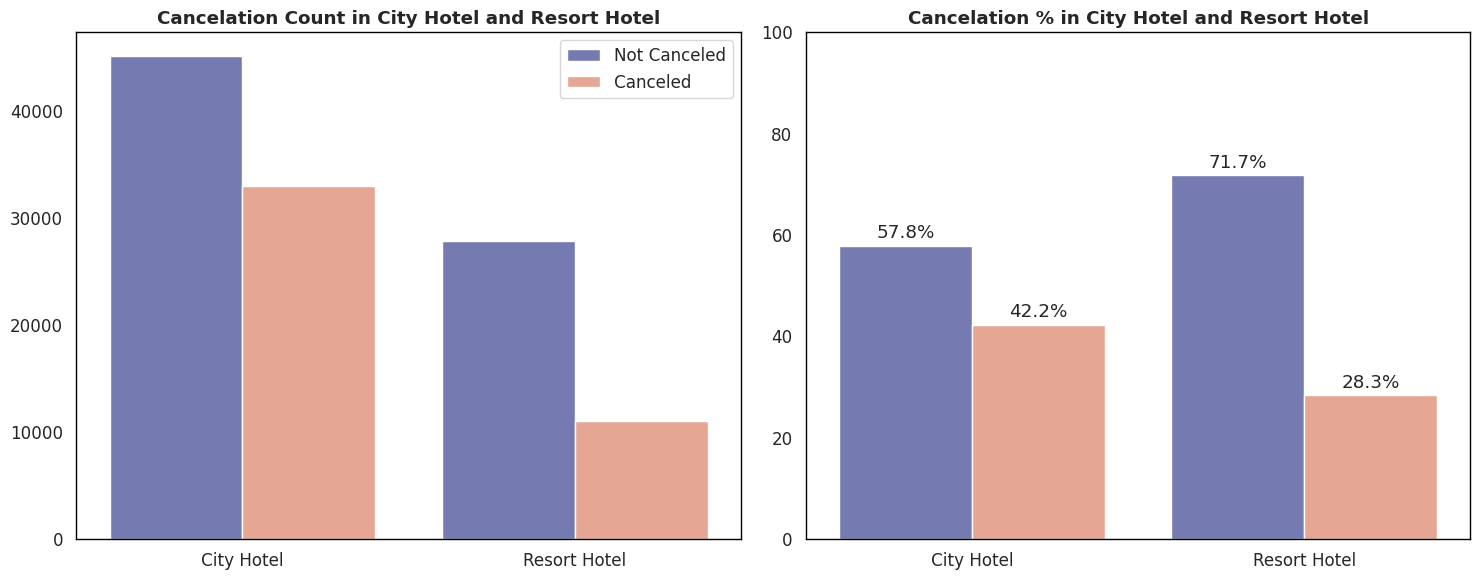

In [ ]:
plot_count_and_percentage(
    df=df,
    x='hotel',
    hue='is_canceled',
    title_abs='Cancelation Count in City Hotel and Resort Hotel',
    title_rel = 'Cancelation % in City Hotel and Resort Hotel'
)

## ✅ Customer Type

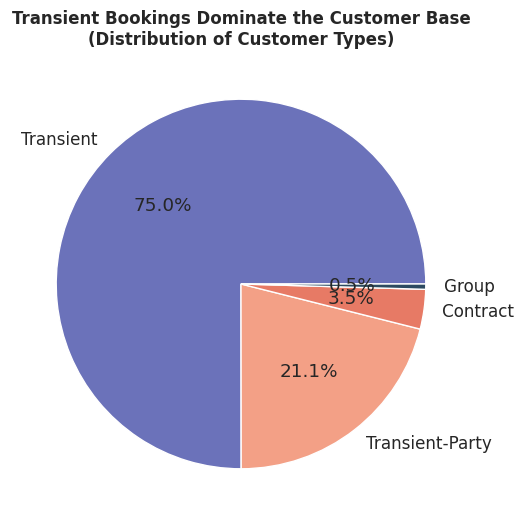

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
customer_type_count = df['customer_type'].value_counts()
ax.pie(customer_type_count, labels=customer_type_count.index, autopct='%.1f%%')

ax.set_title("Transient Bookings Dominate the Customer Base\n(Distribution of Customer Types)",fontweight="bold", size=12)

plt.show()

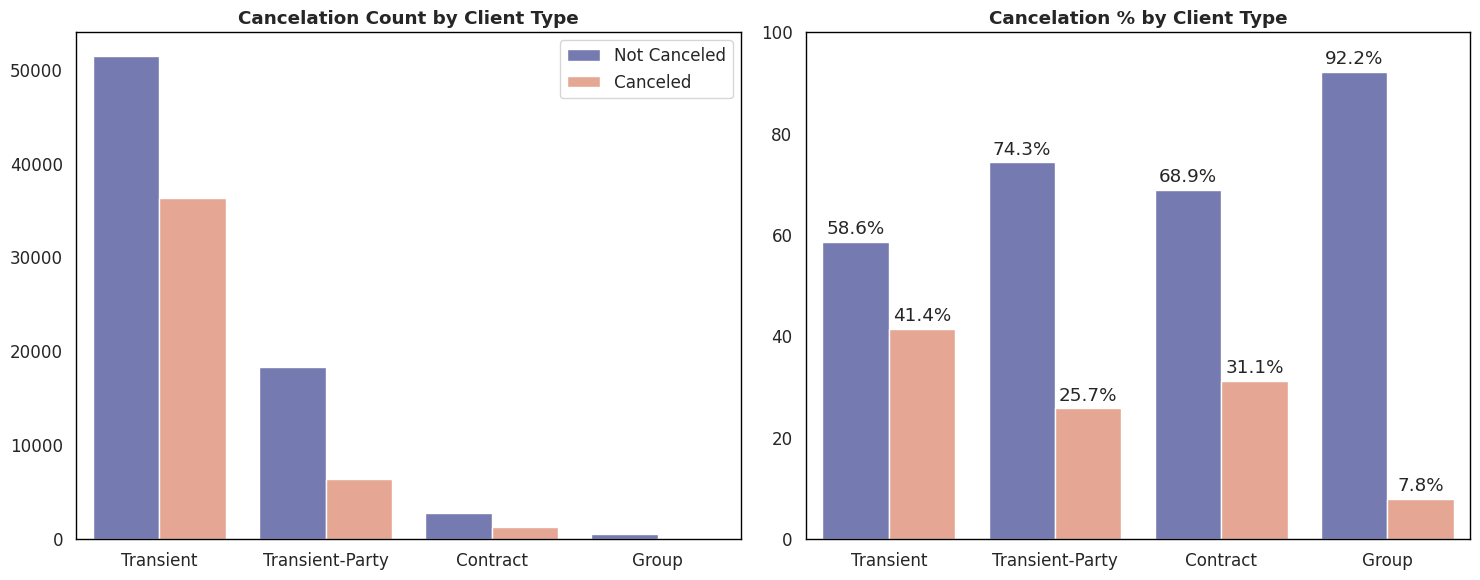

In [ ]:
plot_count_and_percentage(
    df=df,
    x='customer_type',
    hue='is_canceled',
    title_abs='Cancelation Count by Client Type',
    title_rel = 'Cancelation % by Client Type'
)

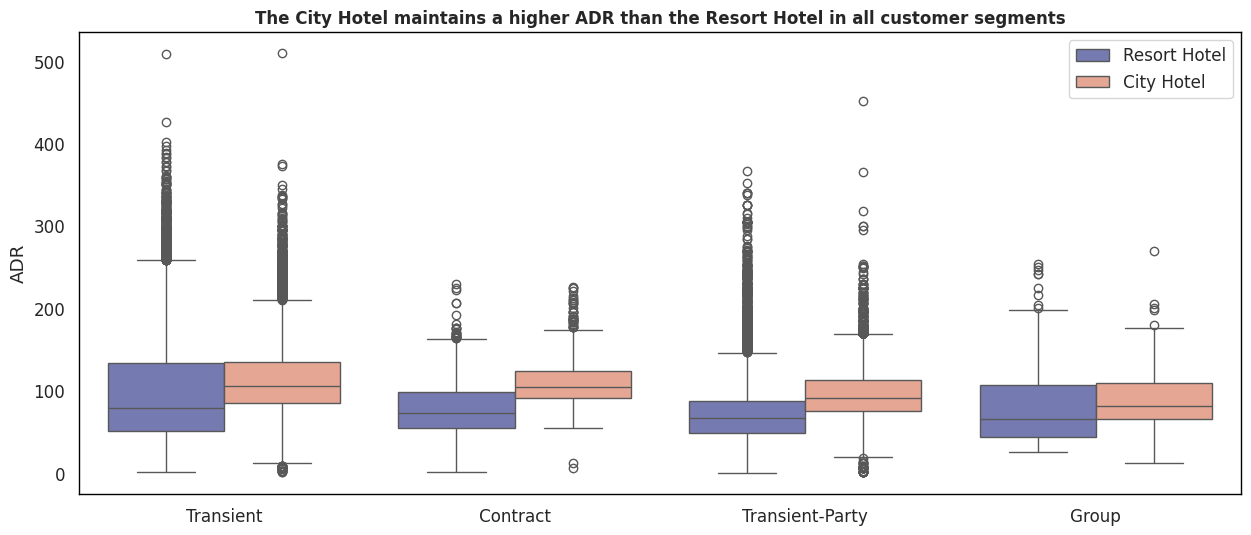

In [ ]:
plt.figure(figsize=(15,6))

ax = sns.boxplot(
    data=df[df.is_canceled_numeric==0],
    x='customer_type',
    y='adr',
    hue='hotel',
)

ax.set_title("The City Hotel maintains a higher ADR than the Resort Hotel in all customer segments",fontweight="bold", size=12)
ax.set(xlabel=None, ylabel='ADR')
ax.legend(title=False)
plt.show()

## ✅ New Guest vs. Repeated Guest

Text(0.5, 1.0, 'New Guest Dominates the Customer Base')

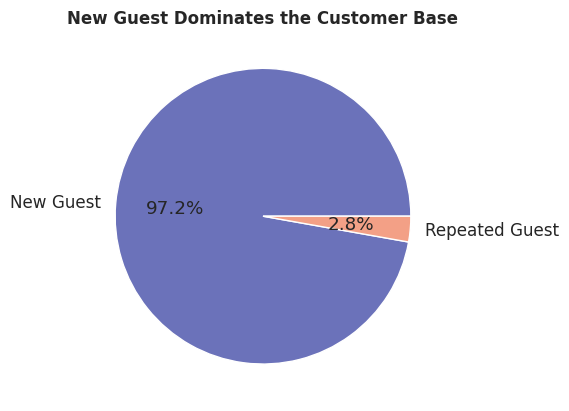

In [ ]:
ax = df['is_repeated_guest'].value_counts().plot(kind='pie', autopct='%1.1f%%')

ax.set(xlabel=None, ylabel=None)
plt.title("New Guest Dominates the Customer Base",fontweight="bold", size=12)

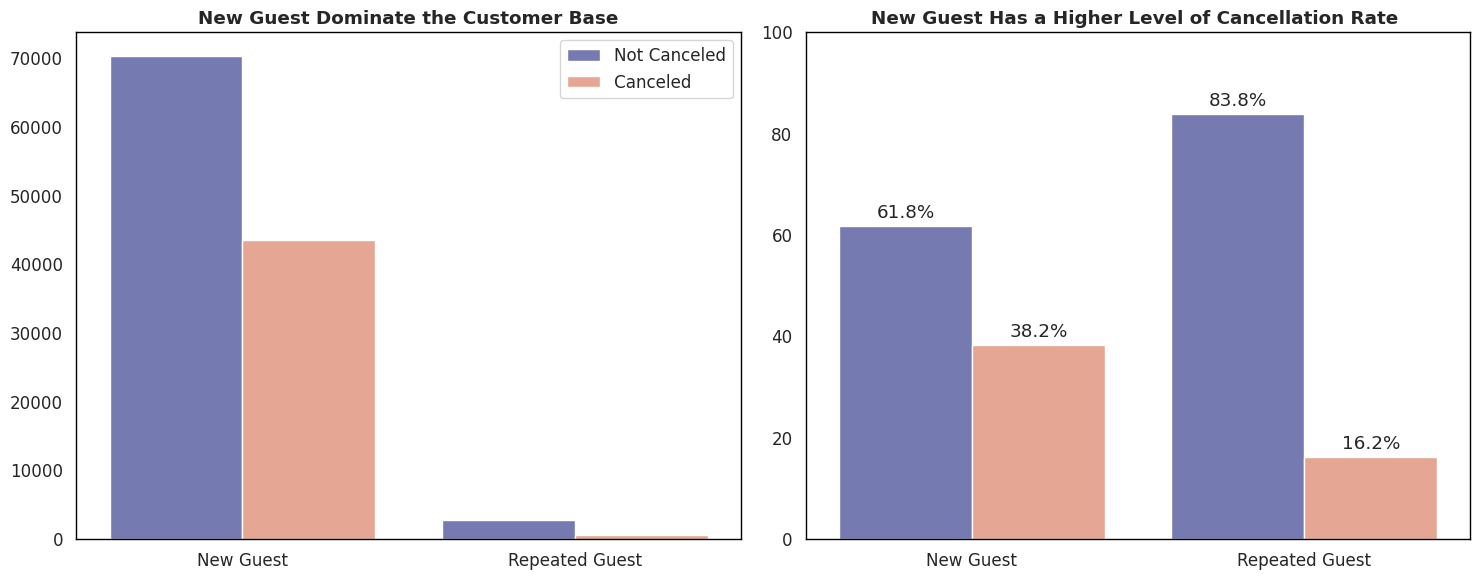

In [ ]:
plot_count_and_percentage(
    df=df,
    x='is_repeated_guest',
    hue='is_canceled',
    title_abs='New Guest Dominate the Customer Base',
    title_rel = 'New Guest Has a Higher Level of Cancellation Rate '
)

The cancellation rate for repeated customers was 16.2%, while the cancellation rate for new customers reached 38.2%, 24 percentage points higher than that for repeated customers.

## ✅ Deposit Type: No Deposit, No Refund, Refundable

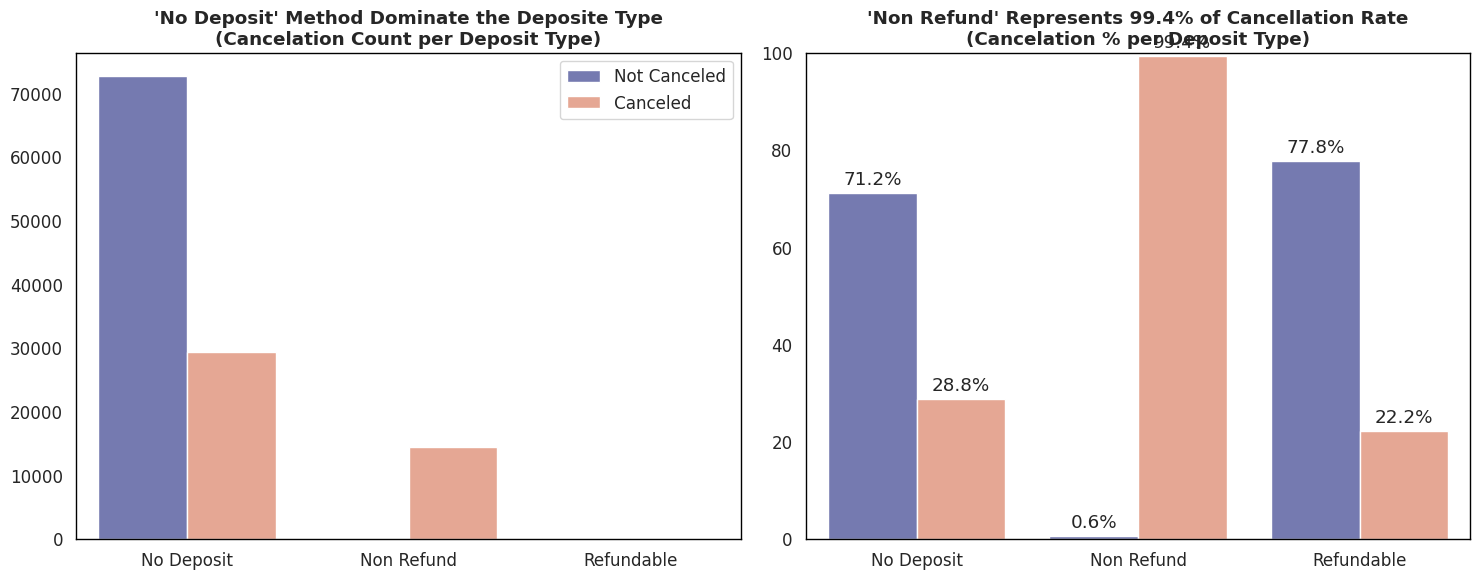

In [ ]:
plot_count_and_percentage(
    df=df,
    x='deposit_type',
    hue='is_canceled',
    title_abs="'No Deposit' Method Dominate the Deposite Type\n(Cancelation Count per Deposit Type)",
    title_rel = "'Non Refund' Represents 99.4% of Cancellation Rate\n(Cancelation % per Deposit Type)"
)

No deposit bookings are the most popular option with a low cancellation rate, while non-refundable deposit bookings have a cancellation rate as high as 99%. Reducing the use of this type of deposit option can help lower customer cancellation rates.

## ✅ Person Count

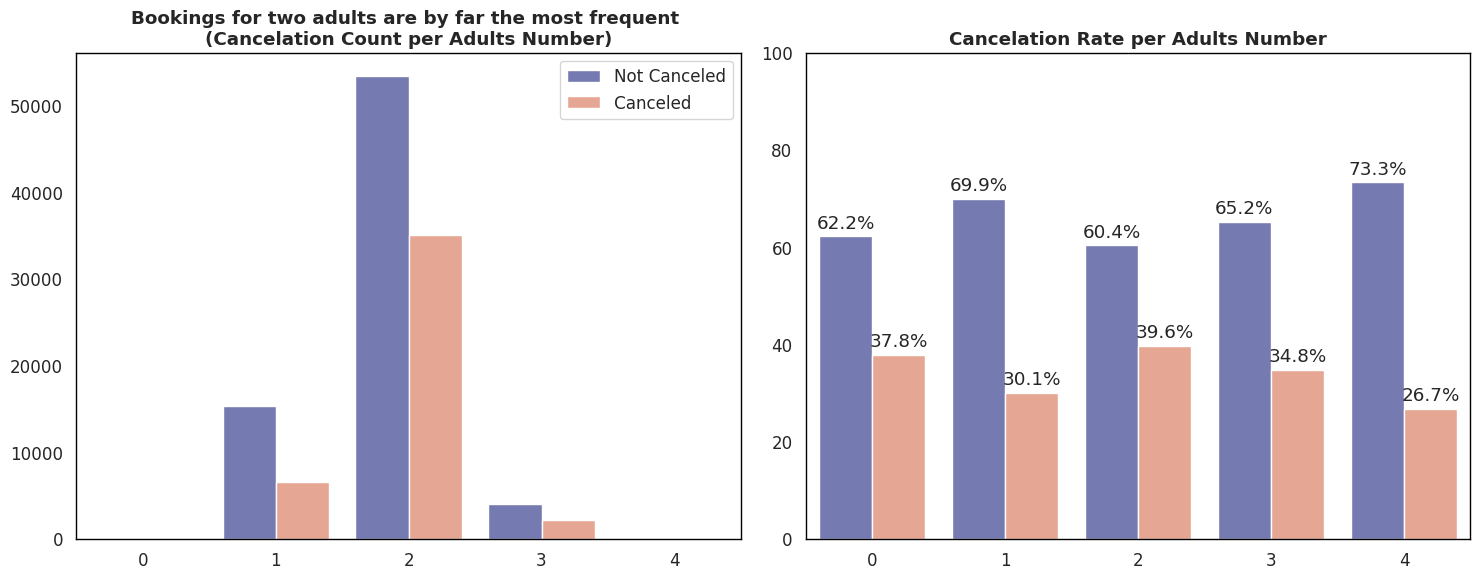

In [ ]:
plot_count_and_percentage(
    df=df,
    x='adults',
    hue='is_canceled',
    order=[0, 1, 2, 3, 4],
    title_abs='Bookings for two adults are by far the most frequent \n(Cancelation Count per Adults Number)',
    title_rel = 'Cancelation Rate per Adults Number'
)

Bookings for two adults are by far the most frequent, but they also present the highest cancellation rate at nearly 40%.

## ✅ Previous Cancellation Count

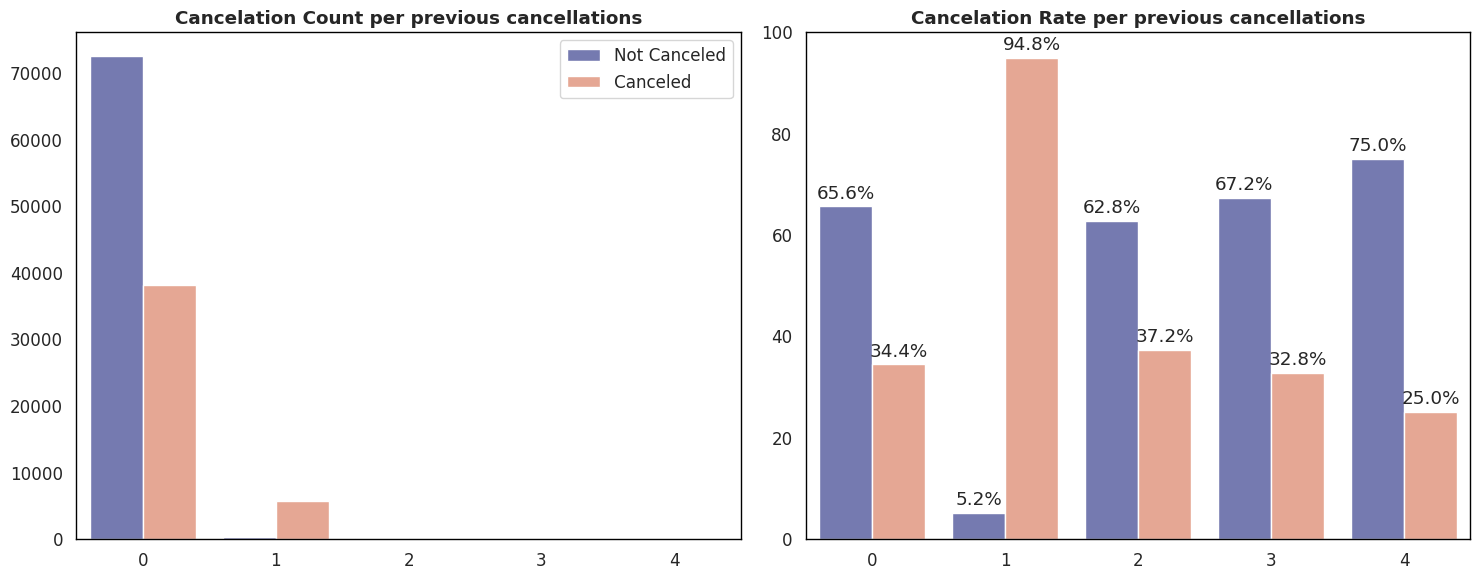

In [ ]:
plot_count_and_percentage(
    df=df,
    x='previous_cancellations',
    hue='is_canceled',
    order=[0, 1, 2, 3, 4],
    title_abs='Cancelation Count per previous cancellations',
    title_rel = 'Cancelation Rate per previous cancellations'
)

A history of exactly one prior cancellation is a massive risk indicator, as the likelihood of that customer canceling again skyrockets to almost 95%.

## ✅ Not Canceled Booking Number

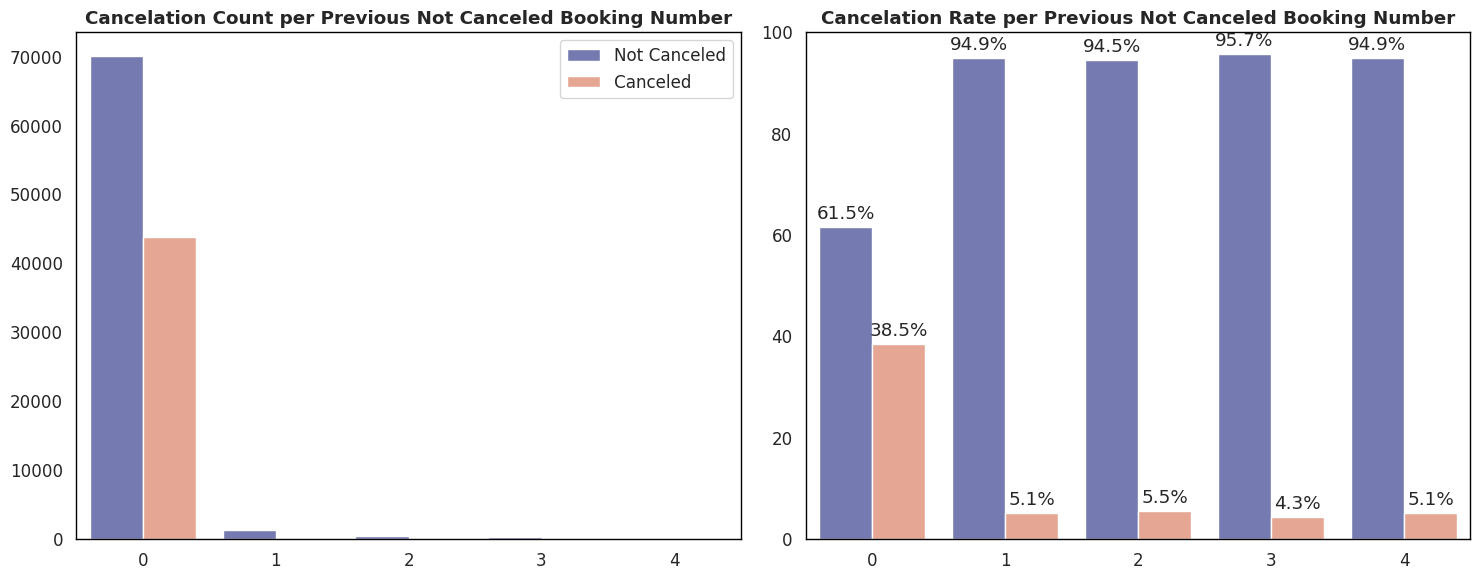

In [ ]:
plot_count_and_percentage(
    df=df,
    x='previous_bookings_not_canceled',
    hue='is_canceled',
    order=[0, 1, 2, 3, 4],
    title_abs='Cancelation Count per Previous Not Canceled Booking Number',
    title_rel = 'Cancelation Rate per Previous Not Canceled Booking Number'
)

Completing just one successful previous stay builds tremendous customer loyalty, causing future cancellation rates to plummet to approximately 5%.

## ✅ Room Type

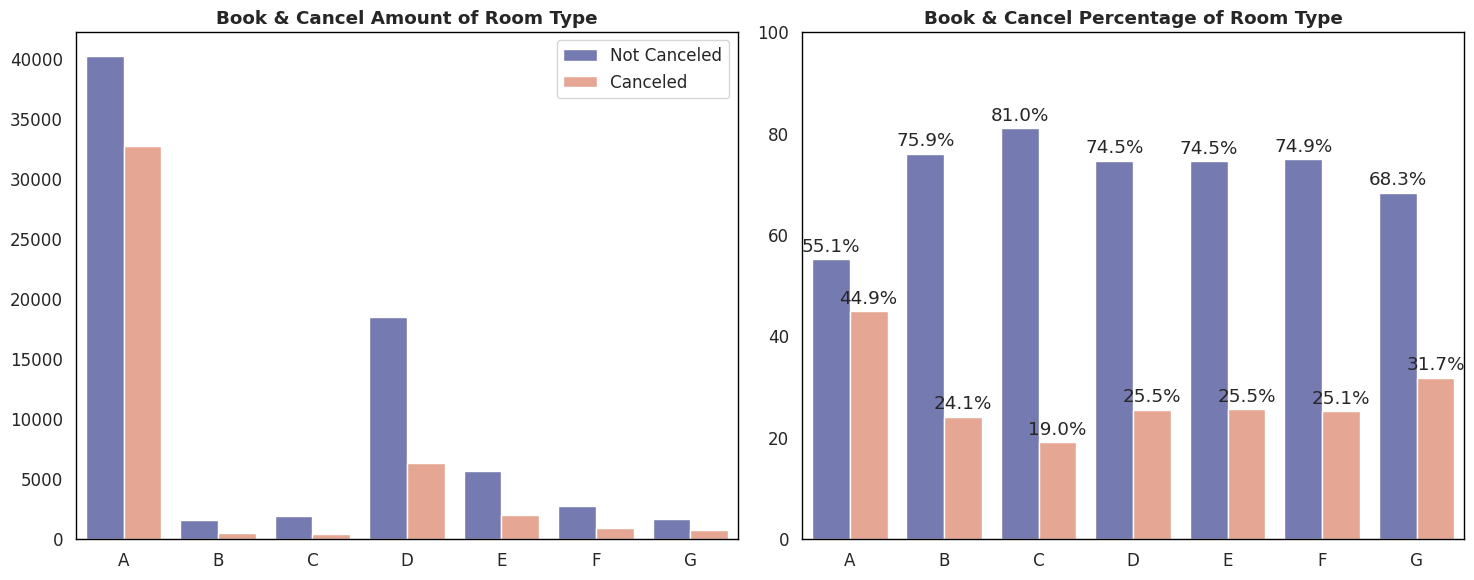

In [ ]:
plot_count_and_percentage(
    df=df,
    x='assigned_room_type',
    hue='is_canceled',
    order= ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    title_abs='Book & Cancel Amount of Room Type',
    title_rel = 'Book & Cancel Percentage of Room Type'
)

Among the top 7 room types in terms of booking volume, room types A and G had higher cancellation rates than other room types, with room type A's cancellation rate reaching as high as 44.9%.

# ✅ Correlation Check

<Axes: >

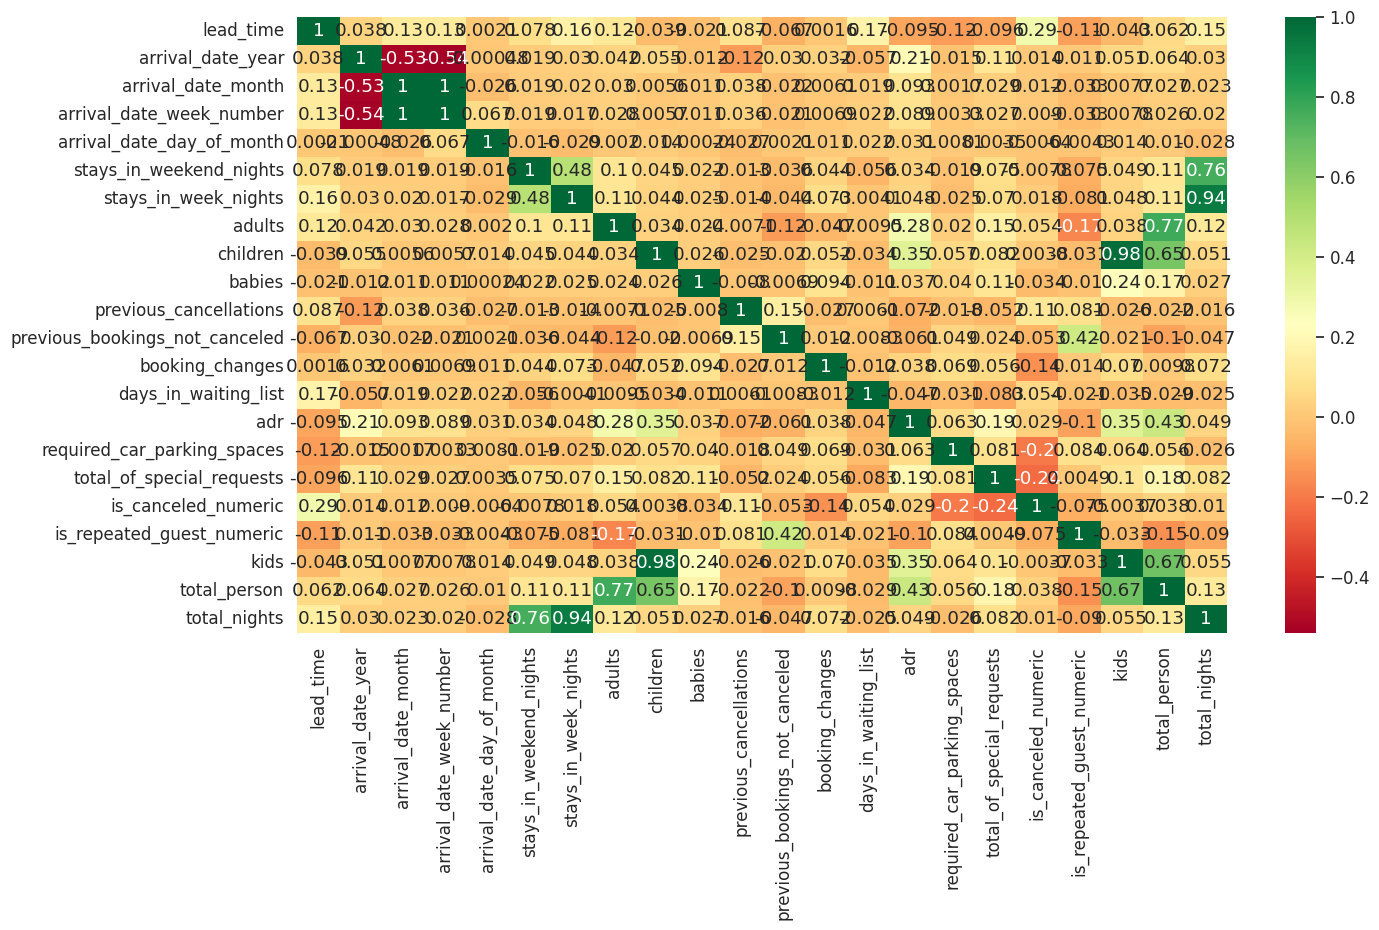

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='RdYlGn')

In [ ]:
correlation = df.corr(numeric_only=True)['is_canceled_numeric'].abs().sort_values(ascending=False)
correlation

,is_canceled_numeric
is_canceled_numeric,1.000000
lead_time,0.289238
total_of_special_requests,0.238344
required_car_parking_spaces,0.196806
booking_changes,0.144934
previous_cancellations,0.110446
is_repeated_guest_numeric,0.074919
days_in_waiting_list,0.053917
adults,0.053855
previous_bookings_not_canceled,0.052862


## ✅ Does the ADR impact a lot on the Cancellation Rate?

In [ ]:
bins = range(0, 300, 20)
df['adr_bin'] = pd.cut(df['adr'], bins=bins)

adr_cancel_rate = df.groupby('adr_bin')['is_canceled_numeric'].mean().reset_index()

adr_cancel_rate['adr_bin_mid'] = adr_cancel_rate['adr_bin'].apply(lambda x: x.mid)
adr_cancel_rate

,adr_bin,is_canceled_numeric,adr_bin_mid
0,"(0, 20]",0.459057,10.0
1,"(20, 40]",0.219848,30.0
2,"(40, 60]",0.271355,50.0
3,"(60, 80]",0.429051,70.0
4,"(80, 100]",0.370259,90.0
5,"(100, 120]",0.393696,110.0
6,"(120, 140]",0.399194,130.0
7,"(140, 160]",0.362574,150.0
8,"(160, 180]",0.379939,170.0
9,"(180, 200]",0.370257,190.0


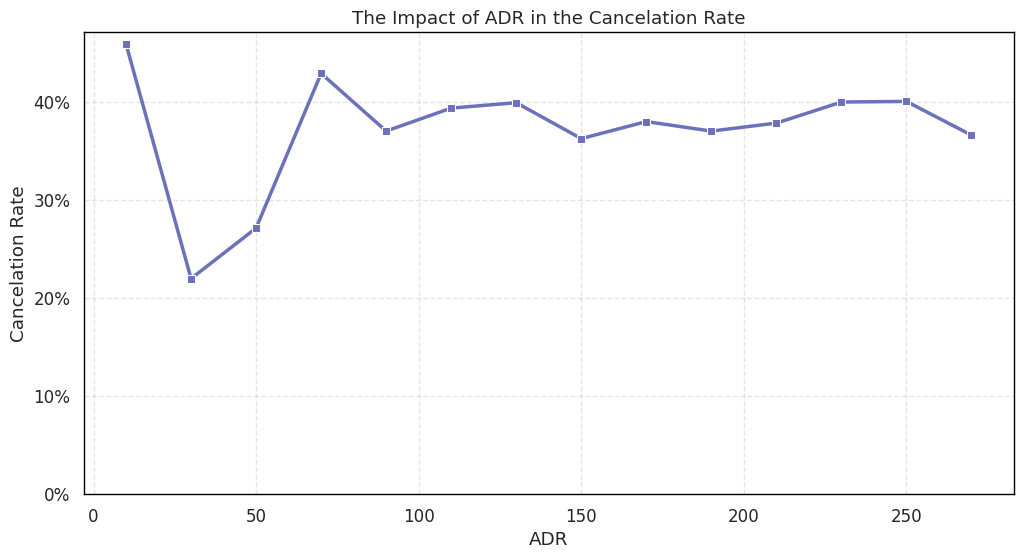

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.lineplot(
    data=adr_cancel_rate,
    x='adr_bin_mid',
    y='is_canceled_numeric',
    marker='s',
    linewidth=2.5
)

ax.set(
    title='The Impact of ADR in the Cancelation Rate',
    xlabel='ADR',
    ylabel='Cancelation Rate'
)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1,0))

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

The ADR doesn´t show as a strong indicator for cancellation rate.

###

## ✅ How the Special Request impact a lot on the Cancellation Rate?

In [ ]:
special_request_df = df.groupby('total_of_special_requests')['is_canceled_numeric'].mean().reset_index()
special_request_df

,total_of_special_requests,is_canceled_numeric
0,0,0.484749
1,1,0.222972
2,2,0.223639
3,3,0.181369
4,4,0.108359
5,5,0.026316


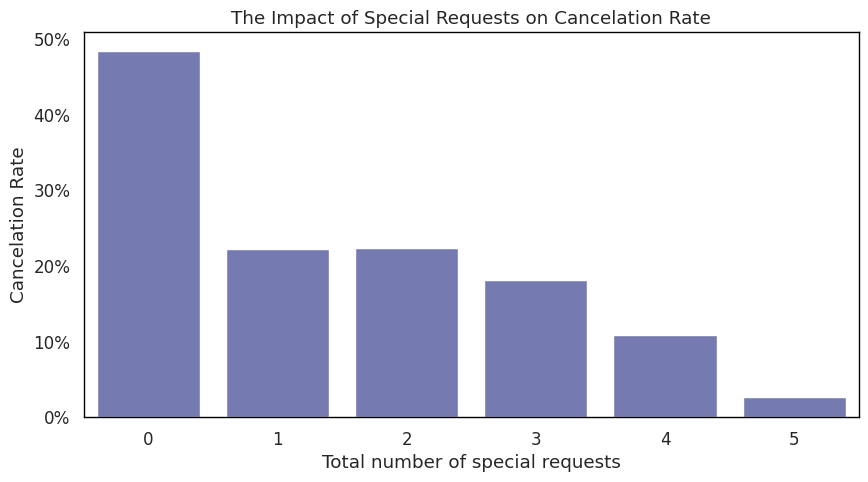

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df,
    x='total_of_special_requests',
    y='is_canceled_numeric',
    errorbar=None,
    legend=False
)
ax.set_title('The Impact of Special Requests on Cancelation Rate')
ax.set_xlabel('Total number of special requests')
ax.set_ylabel('Cancelation Rate')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

When the guest has more special requests, there is less posibility for him/her to cancel the booking

## ✅ Do the length of Lead Time impact on the Cancellation Rate?

In [ ]:
bins = range(0, 350, 30)
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=bins)

lead_cancel_rate = df.groupby('lead_time_bin')['is_canceled_numeric'].mean().reset_index()
lead_cancel_rate['lead_time_mid'] = lead_cancel_rate['lead_time_bin'].apply(lambda x: x.mid)
lead_cancel_rate

,lead_time_bin,is_canceled_numeric,lead_time_mid
0,"(0, 30]",0.212853,15.0
1,"(30, 60]",0.366565,45.0
2,"(60, 90]",0.396903,75.0
3,"(90, 120]",0.447614,105.0
4,"(120, 150]",0.440464,135.0
5,"(150, 180]",0.459913,165.0
6,"(180, 210]",0.453445,195.0
7,"(210, 240]",0.474458,225.0
8,"(240, 270]",0.545859,255.0
9,"(270, 300]",0.648077,285.0


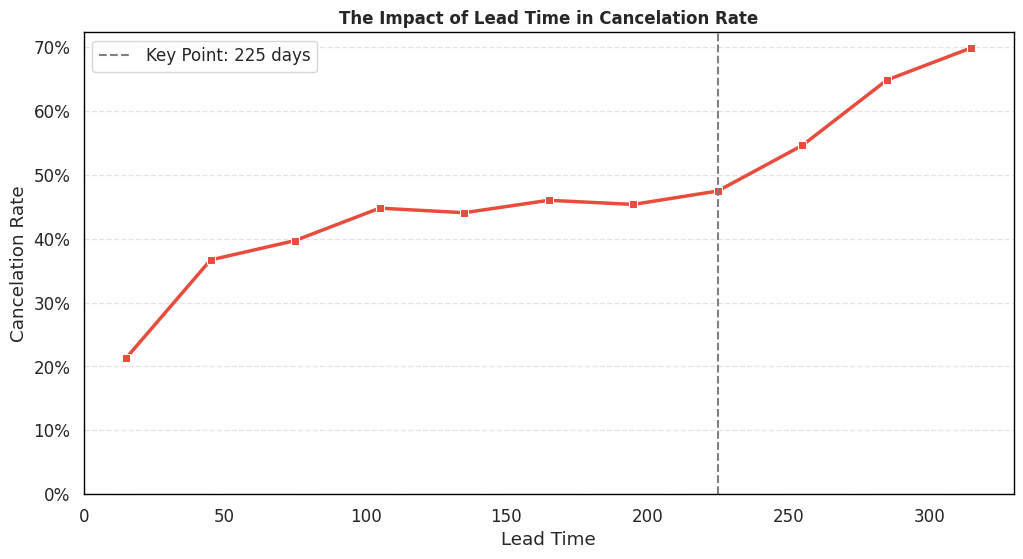

In [ ]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x='lead_time_mid',
    y='is_canceled_numeric',
    data=lead_cancel_rate,
    marker='s',
    color='#e74c3c',
    linewidth=2.5
)
ax.set_title('The Impact of Lead Time in Cancelation Rate', fontweight="bold", size=12)
ax.set_xlabel('Lead Time')
ax.set_ylabel('Cancelation Rate')
ax.set_ylim(bottom=0)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1,0))
plt.axvline(x=225, color='gray', linestyle='--', label='Key Point: 225 days')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

The data reveals a clear positive correlation between lead time and cancellation risk, indicating that bookings made further in advance are significantly more likely to be canceled. Notably, there is a sharp spike in cancellations for reservations made more than 225 days prior to arrival, eventually peaking at nearly 70%.

# ✅  From where are the most guests coming from?

In [ ]:
confirmed_df = df[df['is_canceled'] == 'Not Canceled'].copy()

confirmed_df_country = confirmed_df['country'].value_counts().reset_index()
confirmed_df_country.columns = ['country', 'Guests Number']
confirmed_df_country

,country,Guests Number
0,PRT,19694
1,GBR,9600
2,FRA,8427
3,ESP,6312
4,DEU,6028
...,...,...
160,KIR,1
161,ATF,1
162,TJK,1
163,SLE,1


In [ ]:
import plotly.express as px

fig = px.choropleth(
    confirmed_df_country,
    locations = 'country',
    color='Guests Number',
    hover_name= 'country',
    color_continuous_scale=px.colors.sequential.GnBu,
    title=" Home Country of Visitors"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()

## ✅ Market Segment and Distribution Channel

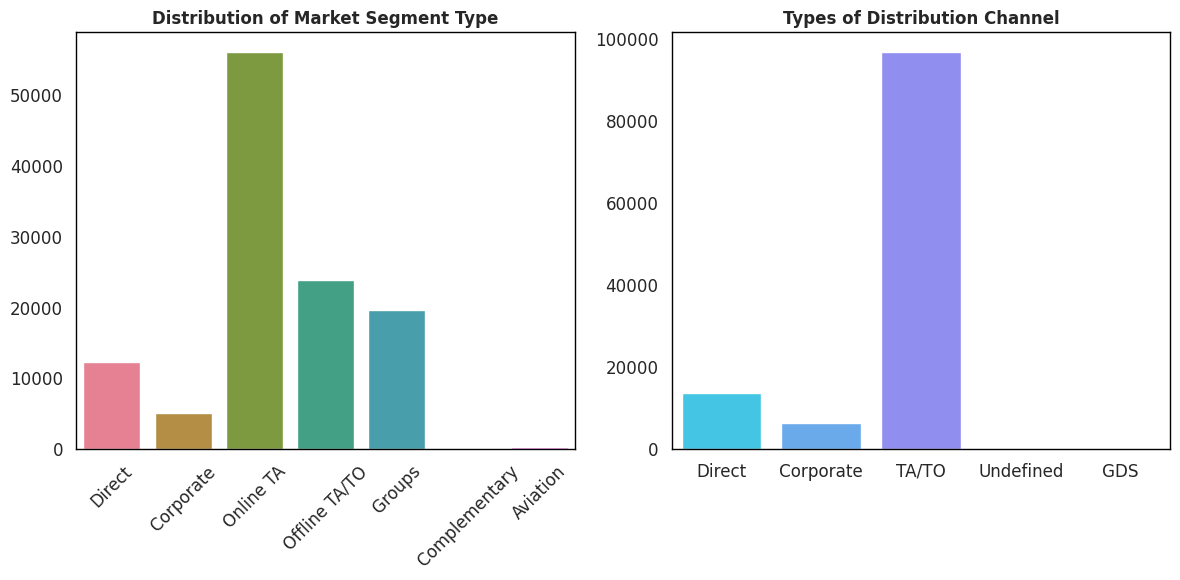

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(
    data=df,
    x='market_segment',
    hue='market_segment',
    ax= axes[0]
)

axes[0].set_title('Distribution of Market Segment Type' , fontweight="bold", size=12)
axes[0].set(xlabel=None, ylabel=None)
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(
    data=df,
    x='distribution_channel',
    ax= axes[1],
    palette='cool'
)

axes[1].set_title('Types of Distribution Channel' , fontweight="bold", size=12)
axes[1].set(xlabel=None, ylabel=None)

plt.tight_layout()
plt.show()

## ✅  Resort Hotel o City Hotel?


Text(0.5, 1.0, 'City Hotel vs. Resort Hotel ')

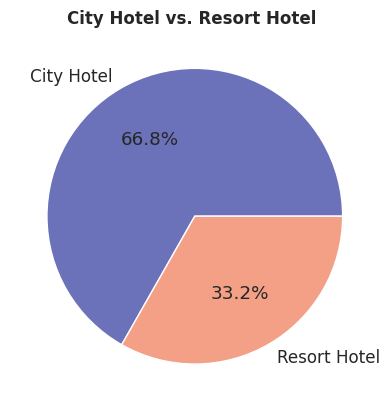

In [ ]:
ax = df['hotel'].value_counts().plot(kind='pie', autopct='%1.1f%%')

ax.set(xlabel=None, ylabel=None)
plt.title("City Hotel vs. Resort Hotel ",fontweight="bold", size=12)

##  ✅ How does the price vary per night over the year?

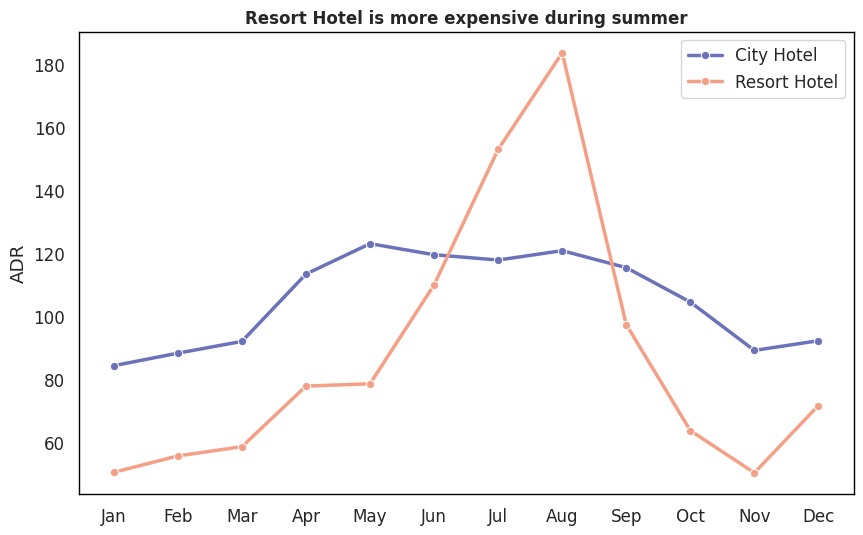

In [ ]:
monthly_adr = confirmed_df.groupby(['hotel', 'arrival_date_month'])['adr'].mean().reset_index(name='avg_adr')

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    x='arrival_date_month',
    y='avg_adr',
    hue='hotel',
    marker='o',
    linewidth=2.5,
    data=monthly_adr
)

ax.set_title('Resort Hotel is more expensive during summer', fontweight="bold", size=12)
ax.set(xlabel=None, ylabel='ADR')
ax.legend(title=None)

ax.set_xticks(range(1,13))
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(months_labels)

plt.show()

###

This plot clearly shows that prices in the Resort Hotel are much higher during the summer and prices of city hotel varies less and is a bit more expensive during Spring Summer and Autumn .




## ✅ Which are the most busy months?


## Only check the 2016

During the initial analysis, I noticed an anomaly in the summer months (July and August). Upon investigating the dataset, I discovered that the data was imbalanced: we had three years of data for the summer, but only two years for the remaining months. To prevent skewed averages (as the baseline customer volume changes annually), I made the analytical decision to isolate the year 2016, which is the only one with a complete annual cycle (January - December). This provides us with the purest and most realistic view of the business's seasonality.

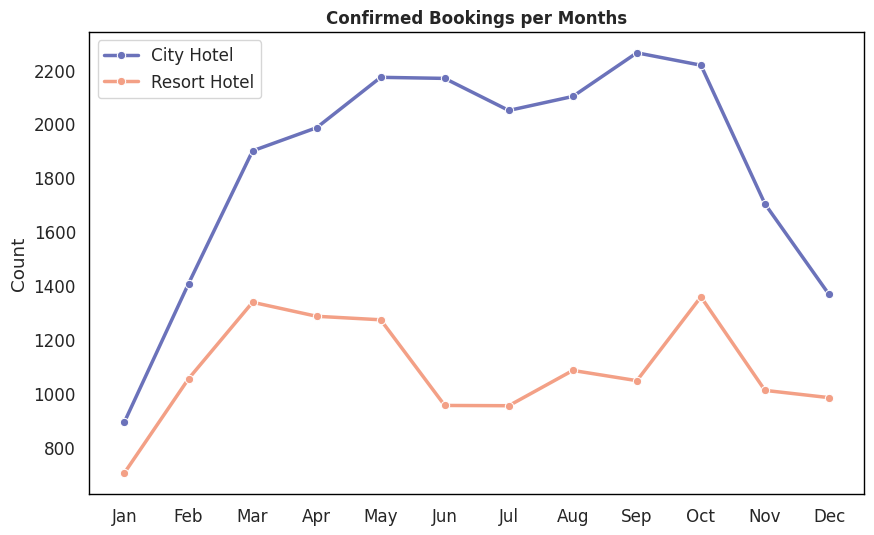

In [ ]:
confirmed_2016 = confirmed_df[confirmed_df['arrival_date_year'] == 2016]

monthly_bookings_2016 = confirmed_2016.groupby(['hotel', 'arrival_date_month']).size().reset_index(name='confirmed_bookings')

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    x='arrival_date_month',
    y='confirmed_bookings',
    hue='hotel',
    marker='o',
    linewidth=2.5,
    data=monthly_bookings_2016
)

ax.set_title('Confirmed Bookings per Months', fontweight="bold", size=12)
ax.set(xlabel=None, ylabel='Count')
ax.legend(title=None)

ax.set_xticks(range(1,13))
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(months_labels)

plt.show()


* Consistent Volume Dominance: The City Hotel consistently secures a higher volume of confirmed bookings than the Resort Hotel throughout the entire year. The gap between the two properties widens significantly during the summer and early autumn months.


* The Winter Slump: Both establishments share a common low season. November, December, and January represent the weakest months for confirmed bookings across the board, which aligns with standard off-season trends in the hospitality industry.



## ✅ How long do people stay at the hotels?

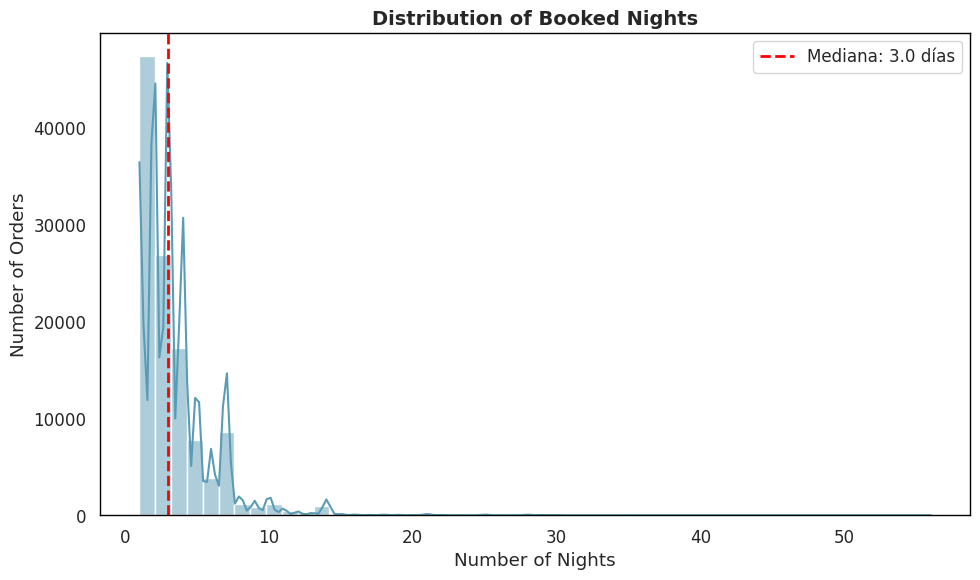

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x='total_nights',
    bins=50,
    kde=True,
    color='#5A9CB5',
    edgecolor='white'
)

median_nights = df['total_nights'].median()
plt.axvline(
    x=median_nights,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {median_nights} días'
)

ax.set_title("Distribution of Booked Nights", fontweight="bold", size=14)
ax.set_xlabel("Number of Nights")
ax.set_ylabel("Number of Orders")

plt.legend()

plt.tight_layout()
plt.show()

## ✅ How long ahead do people plan the hotel booking?

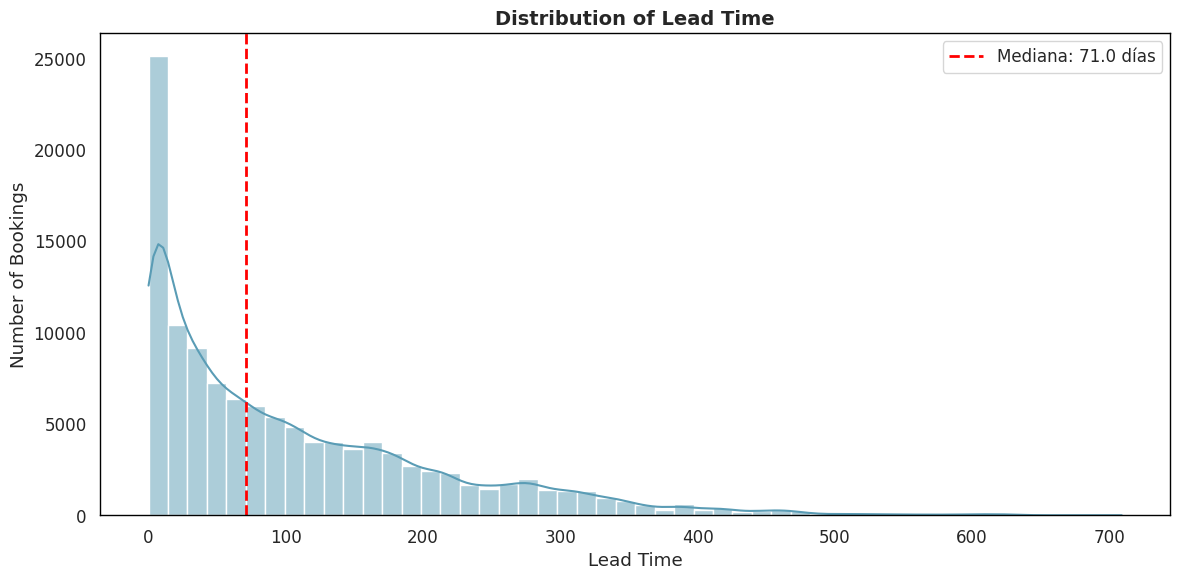

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df,
    x='lead_time',
    bins=50,
    kde=True,
    color='#5A9CB5',
    edgecolor='white'
)

median_lead_time = df['lead_time'].median()
plt.axvline(
    x=median_lead_time,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {median_lead_time} días'
)

ax.set_title("Distribution of Lead Time", fontweight="bold", size=14)
ax.set_xlabel("Lead Time")
ax.set_ylabel("Number of Bookings")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'is_canceled_numeric',
       'is_repeated_guest_numeric', 'kids', 'total_person', 'total_nights',
       'complete_arrival_date', 'adr_bin', 'lead_time_bin'],
      dtype='object')

## ✅Download the Data as .csv

In [ ]:
df.to_csv('hotel_bookings_cleaned.csv', index=False)